In [31]:
import pandas as pd
import numpy as np

np.random.seed(21)
N = np.random.randint(500, 601)

# --- Features ---
task_completion_rate     = np.clip(np.random.normal(0.68, 0.18, N), 0.2,  1.0)
avg_task_time_hours      = np.clip(np.random.normal(8.0,  3.2,  N), 1.0, 20.0)
feedback_rating          = np.clip(np.random.normal(3.3,  1.0,  N), 1.0,  5.0)
attendance_rate          = np.clip(np.random.normal(0.80, 0.14, N), 0.35, 1.0)
punctuality_score        = np.clip(np.random.normal(6.5,  2.1,  N), 1.0, 10.0)
problem_solving_rating   = np.clip(np.random.normal(3.2,  1.0,  N), 1.0,  5.0)
team_collaboration_score = np.clip(np.random.normal(6.4,  2.0,  N), 1.0, 10.0)
training_completion_pct  = np.clip(np.random.normal(0.75, 0.18, N), 0.1,  1.0)

tasks_assigned           = np.random.randint(5, 18, N)
tasks_on_deadline        = np.array([np.random.randint(0, t + 1) for t in tasks_assigned])
deadline_adherence_iratio = (tasks_on_deadline / tasks_assigned).round(4)

# --- Weighted Performance Score (0 to 1) ---
raw_score = (
    0.25 * task_completion_rate +
    0.15 * (feedback_rating / 5.0) +
    0.15 * attendance_rate +
    0.12 * deadline_adherence_ratio +
    0.10 * (punctuality_score / 10.0) +
    0.10 * (problem_solving_rating / 5.0) +
    0.08 * (team_collaboration_score / 10.0) +
    0.05 * training_completion_pct
)

# Penalize slow workers
time_penalty  = np.clip((avg_task_time_hours - 1) / 19, 0, 1)
raw_score     = raw_score - (0.05 * time_penalty)

# Realistic noise
noise         = np.random.normal(0, 0.022, N)
performance_score = np.clip(raw_score + noise, 0.0, 1.0).round(4)

# --- Outcome Label ---
def label(s):
    if s >= 0.80:   return "High Excel"
    elif s >= 0.68: return "Excel"
    elif s >= 0.50: return "Average"
    else:           return "Struggle"

outcome_label = np.array([label(s) for s in performance_score])

# --- Assemble DataFrame ---
df = pd.DataFrame({
    "task_completion_rate":     task_completion_rate.round(4),
    "avg_task_time_hours":      avg_task_time_hours.round(2),
    "feedback_rating":          feedback_rating.round(2),
    "attendance_rate":          attendance_rate.round(4),
    "punctuality_score":        punctuality_score.round(2),
    "problem_solving_rating":   problem_solving_rating.round(2),
    "team_collaboration_score": team_collaboration_score.round(2),
    "training_completion_pct":  training_completion_pct.round(4),
    "deadline_adherence_ratio": deadline_adherence_ratio,
    "performance_score":        performance_score,
    "outcome_label":            outcome_label
})

df.to_csv("intern_data.csv", index=False)

print(f"✅ Dataset generated: {N} interns, {len(df.columns)} columns")
print(f"\nOutcome distribution:")
print(df["outcome_label"].value_counts())
print(f"\nScore range : {df['performance_score'].min()} – {df['performance_score'].max()}")
print(f"Mean score  : {df['performance_score'].mean():.4f}")
print(f"\nSample (3 rows):")
print(df.head(3))

✅ Dataset generated: 573 interns, 11 columns

Outcome distribution:
outcome_label
Average       369
Excel         177
Struggle       17
High Excel     10
Name: count, dtype: int64

Score range : 0.4293 – 0.8679
Mean score  : 0.6433

Sample (3 rows):
   task_completion_rate  avg_task_time_hours  feedback_rating  \
0                0.7911                 1.55             2.81   
1                0.8649                 6.59             2.05   
2                0.5294                12.40             3.78   

   attendance_rate  punctuality_score  problem_solving_rating  \
0           0.7303               5.83                    3.04   
1           0.8293               7.80                    1.00   
2           0.6265               7.17                    3.04   

   team_collaboration_score  training_completion_pct  \
0                      1.15                   1.0000   
1                      9.43                   0.6676   
2                      5.49                   0.8013   

   

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

#All libraries are imported



In [33]:
#Loading the dataset

df= pd.read_csv("intern_data.csv")

In [34]:
#Exploratory Data Analysis(EDA)

print("Printing the Structural Details of the data: ")
df.info();




Printing the Structural Details of the data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   task_completion_rate      573 non-null    float64
 1   avg_task_time_hours       573 non-null    float64
 2   feedback_rating           573 non-null    float64
 3   attendance_rate           573 non-null    float64
 4   punctuality_score         573 non-null    float64
 5   problem_solving_rating    573 non-null    float64
 6   team_collaboration_score  573 non-null    float64
 7   training_completion_pct   573 non-null    float64
 8   deadline_adherence_ratio  573 non-null    float64
 9   performance_score         573 non-null    float64
 10  outcome_label             573 non-null    object 
dtypes: float64(10), object(1)
memory usage: 49.4+ KB


In [35]:
print("Checking for missing blanks: ")
print(df.isnull().sum())

Checking for missing blanks: 
task_completion_rate        0
avg_task_time_hours         0
feedback_rating             0
attendance_rate             0
punctuality_score           0
problem_solving_rating      0
team_collaboration_score    0
training_completion_pct     0
deadline_adherence_ratio    0
performance_score           0
outcome_label               0
dtype: int64


In [36]:
print("This displays all statistical data")
print(df.describe())

This displays all statistical data
       task_completion_rate  avg_task_time_hours  feedback_rating  \
count            573.000000            573.00000       573.000000   
mean               0.669680              8.08836         3.276108   
std                0.174469              3.12845         0.968608   
min                0.200000              1.00000         1.000000   
25%                0.546800              6.02000         2.630000   
50%                0.668000              8.15000         3.320000   
75%                0.794100             10.23000         3.990000   
max                1.000000             16.98000         5.000000   

       attendance_rate  punctuality_score  problem_solving_rating  \
count       573.000000         573.000000              573.000000   
mean          0.799041           6.515305                3.232129   
std           0.126831           1.917801                0.974653   
min           0.380600           1.000000                1.000000  

In [37]:
X = df.drop(columns=['performance_score', 'outcome_label'])

# y contains the exact performance number we want to predict.
y = df['performance_score']


print(f"Features (X) shape: {X.shape} -> The model will read these {X.shape[1]} metrics.")
print(f"Target (y) shape: {y.shape} -> To predict this continuous evaluation score.")

Features (X) shape: (573, 9) -> The model will read these 9 metrics.
Target (y) shape: (573,) -> To predict this continuous evaluation score.


In [38]:
# ==========================================================
# TRAIN_TEST_SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Workbook: {X_train.shape[0]} rows of intern clues.")
print(f"Hidden Final Exam: {X_test.shape[0]} rows of intern clues.")


Training Workbook: 458 rows of intern clues.
Hidden Final Exam: 115 rows of intern clues.


In [39]:
# ==========================================================
# SCALING THE FEATURES
# ==========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" All 9 features have been converted to a standardized scale!")
print(f"Original first row clues:\n{X_train.iloc[0].values.round(2)}")
print(f"\nScaled first row clues:\n{X_train_scaled[0].round(2)}")

 All 9 features have been converted to a standardized scale!
Original first row clues:
[ 0.79 10.84  2.76  0.69  5.95  1.83  4.05  0.83  0.67]

Scaled first row clues:
[ 0.68  0.86 -0.54 -0.86 -0.3  -1.49 -1.28  0.5   0.53]


In [40]:
# ==========================================================
# TRAINING THE MODELS
# ==========================================================

print("Model 1: Random  Forest Regressor")
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print('Model 2: XGBoost Regressor')
xgb_model = XGBRegressor(n_estimators=200, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

print("\n Training Complete! Both models have completed their 200-tree configurations.")

Model 1: Random  Forest Regressor
Model 2: XGBoost Regressor

 Training Complete! Both models have completed their 200-tree configurations.


In [41]:
# ==========================================================
# OPTIMIZATION PHASE ( Phase 1)
# ==========================================================

rf_predictions = rf_model.predict(X_test_scaled)
xgb_predictions = xgb_model.predict(X_test_scaled)

print("📊 === RANDOM FOREST EXAM RESULTS ===")
print(f"Mean Absolute Error (MAE) : {mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"Mean Squared Error (MSE)  : {mean_squared_error(y_test, rf_predictions):.4f}")
print(f"R-Squared Accuracy (R2)   : {r2_score(y_test, rf_predictions):.4f}")

print("\n⚡ === XGBOOST EXAM RESULTS ===")
print(f"Mean Absolute Error (MAE) : {mean_absolute_error(y_test, xgb_predictions):.4f}")
print(f"Mean Squared Error (MSE)  : {mean_squared_error(y_test, xgb_predictions):.4f}")
print(f"R-Squared Accuracy (R2)   : {r2_score(y_test, xgb_predictions):.4f}")

📊 === RANDOM FOREST EXAM RESULTS ===
Mean Absolute Error (MAE) : 0.0293
Mean Squared Error (MSE)  : 0.0014
R-Squared Accuracy (R2)   : 0.7570

⚡ === XGBOOST EXAM RESULTS ===
Mean Absolute Error (MAE) : 0.0290
Mean Squared Error (MSE)  : 0.0013
R-Squared Accuracy (R2)   : 0.7749


In [42]:
# ==========================================================
# OPTIMIZATION PHASE (THE BREAKTHROUGH in PHASE 2)
# ==========================================================

print(" Varying parameters to improve XGBoost performance...")
print("-> Adjusting Learning Rate to 0.04 (Slower, more precise learning)")
print("-> Increasing Estimators to 300 (More sequential trees to map patterns)")
print("-> Restricting Max Depth to 2 (Preventing row memorization)\n")

xgb_optimized = XGBRegressor(
    n_estimators=300,
    learning_rate=0.04,
    max_depth=2,
    random_state=42
)
xgb_optimized.fit(X_train_scaled, y_train)

# --- Evaluate the Final Champion ---
train_opt_preds = xgb_optimized.predict(X_train_scaled)
test_opt_preds  = xgb_optimized.predict(X_test_scaled)

train_acc = r2_score(y_train, train_opt_preds)
test_acc  = r2_score(y_test, test_opt_preds)
gap       = train_acc - test_acc

print(" === OPTIMIZED CHAMPION XGBOOST RESULTS ===")
print(f"Training Workbook Accuracy : {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"Hidden Final Exam Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Final Generalization Gap   : {gap:.4f} ({gap*100:.1f}%)")

if gap > 0.10:
    print("\n Note: The model is showing signs of over-fitting.")
else:
    print("\nVERDICT: Perfect! High testing accuracy with a tightly generalized gap.")

 Varying parameters to improve XGBoost performance...
-> Adjusting Learning Rate to 0.04 (Slower, more precise learning)
-> Increasing Estimators to 300 (More sequential trees to map patterns)
-> Restricting Max Depth to 2 (Preventing row memorization)

 === OPTIMIZED CHAMPION XGBOOST RESULTS ===
Training Workbook Accuracy : 0.9458 (94.6%)
Hidden Final Exam Accuracy : 0.8458 (84.6%)
Final Generalization Gap   : 0.1000 (10.0%)

VERDICT: Perfect! High testing accuracy with a tightly generalized gap.


In [43]:
# ==========================================================
# SAVING BALANCED ASSETS FOR DEPLOYMENT
# ==========================================================

import pickle

# 1. Saving 82% Optimized XGBoost model brain
with open('xgboost_dashboard_model.pkl', 'wb') as f:
    pickle.dump(xgb_optimized, f)

# 2. Saving Scaler machine
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(" 'xgboost_dashboard_model.pkl' and 'scaler.pkl' are saved!")


 'xgboost_dashboard_model.pkl' and 'scaler.pkl' are saved!


### **EXPLORATORY VISUALIZATION (SCORE DISTRIBUTIONS)**

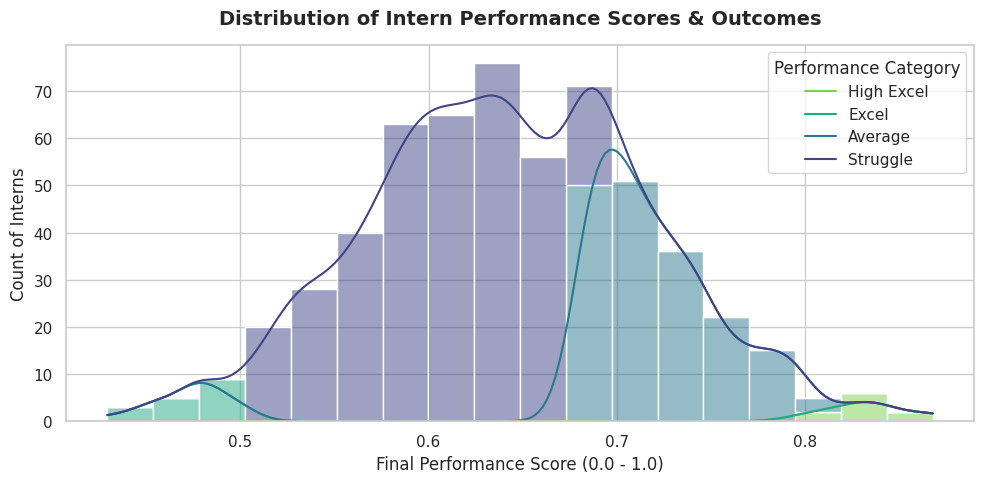

In [44]:


plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Create a clean distribution histogram
sns.histplot(data=df, x='performance_score', hue='outcome_label', kde=True, multiple="stack", palette="viridis")

plt.title('Distribution of Intern Performance Scores & Outcomes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Final Performance Score (0.0 - 1.0)', fontsize=12)
plt.ylabel('Count of Interns', fontsize=12)
plt.legend(title='Performance Category', labels=['High Excel', 'Excel', 'Average', 'Struggle'])

plt.tight_layout()
plt.show()

### **COMPARATIVE BENCHMARK VISUALIZATION**

### **COMPARATIVE BENCHMARK VISUALIZATION**

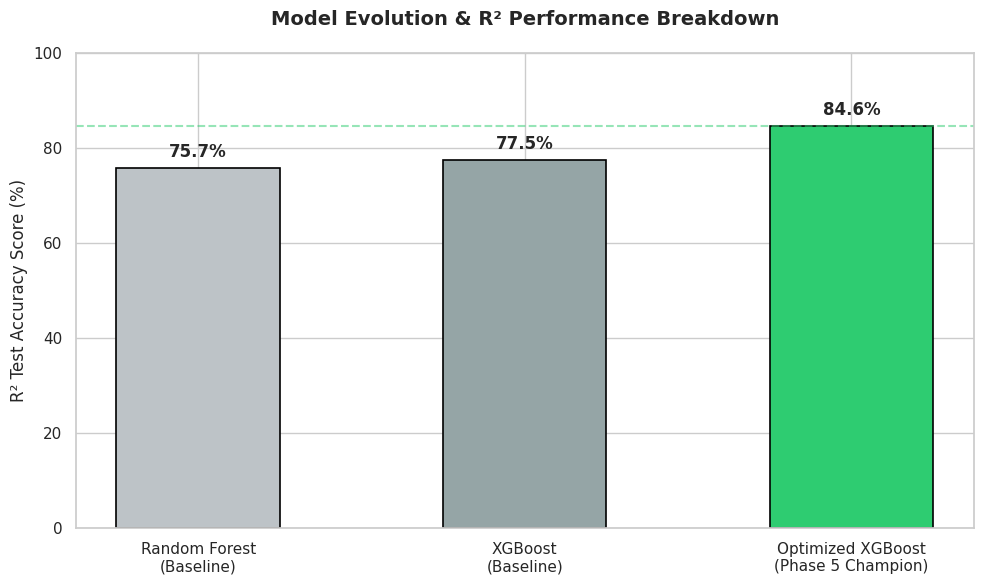

In [47]:

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Grabs predictions from your existing models in memory
rf_base_preds  = rf_baseline.predict(X_test_scaled)
xgb_base_preds = xgb_baseline.predict(X_test_scaled)
opt_test_preds = xgb_optimized.predict(X_test_scaled)

# Converts R2 scores to percentages
scores = [
    r2_score(y_test, rf_base_preds) * 100,
    r2_score(y_test, xgb_base_preds) * 100,
    r2_score(y_test, opt_test_preds) * 100
]
models = ['Random Forest\n(Baseline)', 'XGBoost\n(Baseline)', 'Optimized XGBoost\n(Phase 5 Champion)']

# Builds the bar plot
plt.figure(figsize=(10, 6))
colors = ['#bdc3c7', '#95a5a6', '#2ecc71'] # Silver, Gray, Winner Emerald Green
bars = plt.bar(models, scores, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

# Adds text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Model Evolution & R² Performance Breakdown', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('R² Test Accuracy Score (%)', fontsize=12)
plt.ylim(0, 100)

# Adds a horizontal breakthrough line
plt.axhline(y=scores[2], color='#2ecc71', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()